In [43]:
import random
import numpy as np
import matplotlib.pyplot as plt

## Generates N random points for a given linear separator w
## if wTx > 0, y = 1; if wTx < 0, y = -1. wTx = 0 are discarded
def generate_pla(N=20,w0=0,w1=1,w2=1,w3=0,w4=0,w5=0,w6=0,w7=0,w8=0,w9=0):
    n = 0
    X1 = []
    X2 = []
    Y = []
    while(n < N):
        x1 = random.uniform(-10,10)
        x2 = random.uniform(-10,10)
        y_step = w0 + w1*x1 + w2*x2 + w3*x1*x1 + w4*x1*x2 + w5*x2*x2 + w6*x1*x1*x1 + w7*x1*x2*x2 + w8*x1*x1*x2 + w9*x2*x2*x2
        if(y_step == 0):
            continue
        X1.append(x1)
        X2.append(x2)
        if(y_step > 0):
            Y.append(1)
        elif(y_step < 0):
            Y.append(-1)
        n += 1
    data = [np.array([1,X1[i],X2[i],Y[i]]) for i in range(N)]
    return data

In [47]:
f_w0, f_w1, f_w2, f_w3, f_w4, f_w5, f_w6, f_w7, f_w8, f_w9 = -36, 0, 0, 1, 0, 1, 0, 1, 1, 0
N = 500
data = generate_pla(N, f_w0, f_w1, f_w2, f_w3, f_w4, f_w5, f_w6, f_w7, f_w8, f_w9 )

In [48]:
def abline(slope, intercept):
    """Plot a line from slope and intercept"""
    axes = plt.gca()
    x_vals = np.array(axes.get_xlim())
    y_vals = intercept + slope * x_vals
    plt.plot(x_vals, y_vals, '--', label = "x_2="+str(slope)+"x_1+"+str(intercept) )

def plot4poly(w0,w1,w2,w3,w4,w5,w6,w7,w8,w9,color='red'):
  axes = plt.gca()
  xlims = axes.get_xlim()
  ylims = axes.get_ylim()
  x1 = np.linspace(xlims[0], xlims[1], 1000)
  x2 = np.linspace(ylims[0], ylims[1], 1000)
  # meshgrid
  XM1, XM2 = np.meshgrid(x1, x2)
  def f(x1, x2, w0, w1, w2, w3, w4, w5, w6, w7, w8, w9):
    return w0 + w1*x1 + w2*x2 + w3*x1*x1 + w4*x1*x2 + w5*x2*x2 + w6*x1*x1*x1 + w7*x1*x2*x2 + w8*x1*x1*x2 + w9*x2*x2*x2
  plt.contour(XM1, XM2, f(XM1, XM2, w0,w1,w2,w3,w4,w5,w6,w7,w8,w9), 1, colors = color)

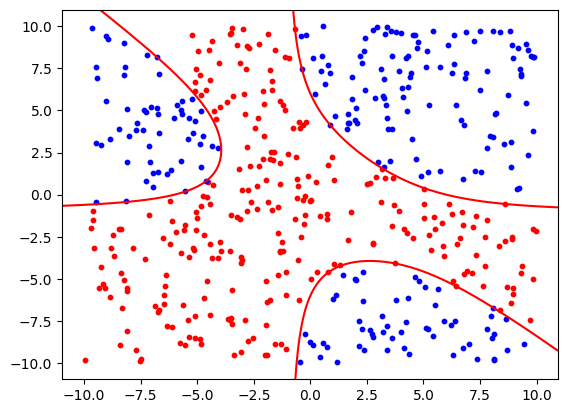

In [49]:
X1 = [i[1] for i in data]
X2 = [i[2] for i in data]
Y  = [i[3] for i in data]
markers = [] #'o' or '+'
colors = [] # 'b' or 'r'
cnt = 0
for i in data:
    if (i[3] == 1):
        plt.scatter(i[1],i[2],c = 'b', s = 10)
    else:
        plt.scatter(i[1],i[2],c = 'r', s = 10)
    cnt += 1

#abline(-f_w1/f_w2,-f_w0/f_w2)
plot4poly(f_w0, f_w1, f_w2, f_w3, f_w4, f_w5, f_w6, f_w7, f_w8, f_w9)
plt.show()

In [54]:
import pandas as pd

df = pd.DataFrame(data)


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       500 non-null    float64
 1   1       500 non-null    float64
 2   2       500 non-null    float64
 3   3       500 non-null    float64
dtypes: float64(4)
memory usage: 15.8 KB


In [56]:
df.drop([0], axis = 1, inplace=True)
df.columns = ['x1', 'x2', 'y']

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      500 non-null    float64
 1   x2      500 non-null    float64
 2   y       500 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


In [58]:
df.to_csv('synthetic_dataset.csv', index=False)